In [ ]:
# importing the libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import IsolationForest
from sklearn.metrics import mean_absolute_error,mean_squared_error,r2_score

In [ ]:
# extracting the dataset
from zipfile import ZipFile
data = '/content/drive/MyDrive/Hourly_Energy_consumption.zip'
with ZipFile(data,'r') as zip:
  zip.extractall()
  print('the dataset is extracted')

the dataset is extracted


In [ ]:
# loading the dataset into dataframe
hourly_data = pd.read_csv('/content/PJME_hourly.csv')

In [ ]:
hourly_data.head()

,Datetime,PJME_MW
0,2002-12-31 01:00:00,26498.0
1,2002-12-31 02:00:00,25147.0
2,2002-12-31 03:00:00,24574.0
3,2002-12-31 04:00:00,24393.0
4,2002-12-31 05:00:00,24860.0


In [ ]:
hourly_data.shape

(145366, 2)

In [ ]:
hourly_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 145366 entries, 0 to 145365
Data columns (total 2 columns):
 #   Column    Non-Null Count   Dtype  
---  ------    --------------   -----  
 0   Datetime  145366 non-null  object 
 1   PJME_MW   145366 non-null  float64
dtypes: float64(1), object(1)
memory usage: 2.2+ MB


In [ ]:
hourly_data.describe()

,PJME_MW
count,145366.000000
mean,32080.222831
std,6464.012166
min,14544.000000
25%,27573.000000
50%,31421.000000
75%,35650.000000
max,62009.000000


In [ ]:
# checking if there is any missing value
hourly_data.isnull().sum()

,0
Datetime,0
PJME_MW,0


Plotting Energy comsumption over Time

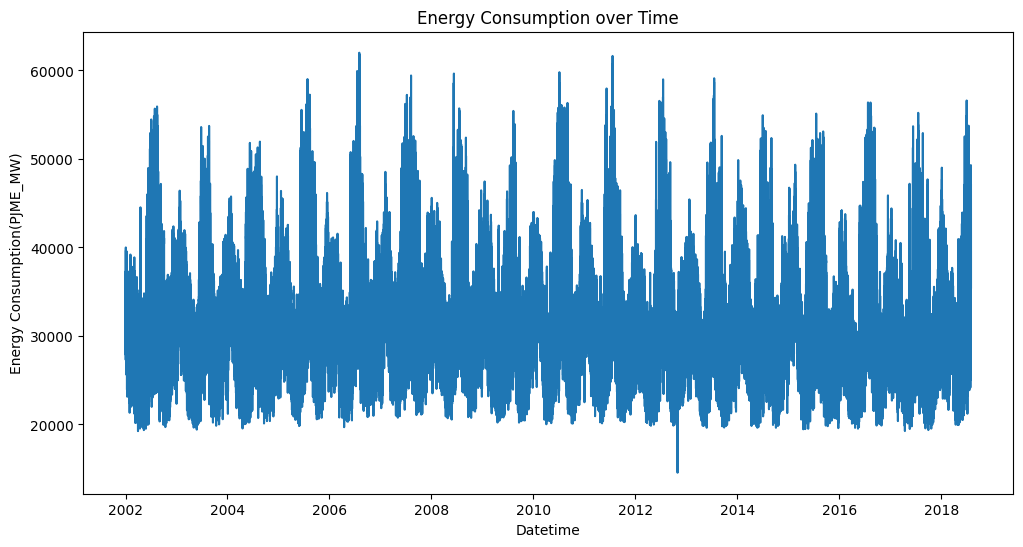

In [42]:
plt.figure(figsize=(12,6))
plt.plot(hourly_data['Datetime'],hourly_data['PJME_MW'])
plt.title('Energy Consumption over Time')
plt.xlabel('Datetime')
plt.ylabel('Energy Consumption(PJME_MW)')
plt.show()

this above plot shows how electricity demands varies over time

Now converting column - Datetime(String) into datetime so that we can extract features like hours,day of week,month

In [17]:
hourly_data['Datetime']= pd.to_datetime(hourly_data['Datetime'])

In [18]:
# now extracting the features
hourly_data['hour']= hourly_data['Datetime'].dt.hour
hourly_data['dayofWeek']= hourly_data['Datetime'].dt.dayofweek
hourly_data['month']= hourly_data['Datetime'].dt.month
hourly_data['dayofYear']= hourly_data['Datetime'].dt.dayofyear
hourly_data['weekand']= hourly_data['Datetime'].dt.dayofweek.isin([5,6]).astype(int)

In [ ]:
hourly_data.head()

,Datetime,PJME_MW
0,2002-12-31 01:00:00,26498.0
1,2002-12-31 02:00:00,25147.0
2,2002-12-31 03:00:00,24574.0
3,2002-12-31 04:00:00,24393.0
4,2002-12-31 05:00:00,24860.0


In [19]:
hourly_data.tail()

,Datetime,PJME_MW,hour,dayofWeek,month,dayofYear,weekand
145361,2018-01-01 20:00:00,44284.0,20,0,1,1,0
145362,2018-01-01 21:00:00,43751.0,21,0,1,1,0
145363,2018-01-01 22:00:00,42402.0,22,0,1,1,0
145364,2018-01-01 23:00:00,40164.0,23,0,1,1,0
145365,2018-01-02 00:00:00,38608.0,0,1,1,2,0


so, we see that this data is not sorted so we will sort it first

In [20]:
hourly_data = hourly_data.sort_values('Datetime')

In [21]:
hourly_data.head()

,Datetime,PJME_MW,hour,dayofWeek,month,dayofYear,weekand
8734,2002-01-01 01:00:00,30393.0,1,1,1,1,0
8735,2002-01-01 02:00:00,29265.0,2,1,1,1,0
8736,2002-01-01 03:00:00,28357.0,3,1,1,1,0
8737,2002-01-01 04:00:00,27899.0,4,1,1,1,0
8738,2002-01-01 05:00:00,28057.0,5,1,1,1,0


In [22]:
#reseting the index
hourly_data = hourly_data.reset_index(drop=True)

In [23]:
hourly_data.head()

,Datetime,PJME_MW,hour,dayofWeek,month,dayofYear,weekand
0,2002-01-01 01:00:00,30393.0,1,1,1,1,0
1,2002-01-01 02:00:00,29265.0,2,1,1,1,0
2,2002-01-01 03:00:00,28357.0,3,1,1,1,0
3,2002-01-01 04:00:00,27899.0,4,1,1,1,0
4,2002-01-01 05:00:00,28057.0,5,1,1,1,0


Now creating input features and target variable to predict

In [24]:
X = hourly_data[['hour','dayofWeek','month','dayofYear','weekand']]
Y = hourly_data['PJME_MW']

In [25]:
X.head()

,hour,dayofWeek,month,dayofYear,weekand
0,1,1,1,1,0
1,2,1,1,1,0
2,3,1,1,1,0
3,4,1,1,1,0
4,5,1,1,1,0


In [26]:
Y.head()

,PJME_MW
0,30393.0
1,29265.0
2,28357.0
3,27899.0
4,28057.0


Plotting the correlation heatmap

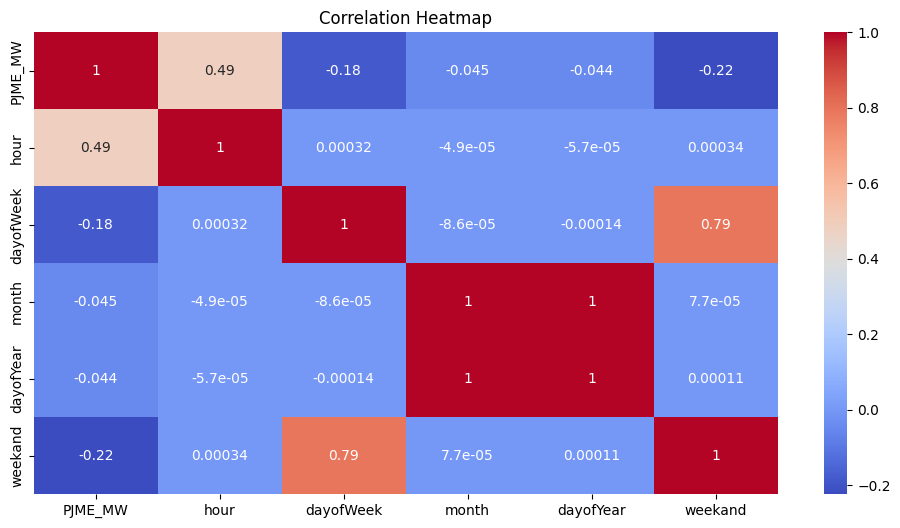

In [27]:
plt.figure(figsize=(12,6))
sns.heatmap(hourly_data.corr(numeric_only=True),annot=True,cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

this heatmap visualizes the relationship between the features and the target variable

Now spilting data into training and testing data

In [28]:
X_train,X_test,Y_train,Y_test = train_test_split(X,Y,test_size=0.2,random_state=3)

In [29]:
X.shape,X_train.shape,X_test.shape

((145366, 5), (116292, 5), (29074, 5))

In [30]:
Y.shape,Y_train.shape,Y_test.shape

((145366,), (116292,), (29074,))

Now training the model

In [31]:
model = RandomForestRegressor(n_estimators=100,random_state =3)

In [32]:
model.fit(X_train,Y_train)

RandomForestRegressor(random_state=3)

In [33]:
Y_predicted= model.predict(X_test)

Now testing the predicted value

In [34]:
Y_predicted[:5]

array([28438.64995238, 42390.98      , 31860.98333333, 33967.23616667,
       27841.03333333])

so above there are first 5 different predicted energy values

now comparing from actual value

In [35]:
Y_test.head()

,PJME_MW
130945,29158.0
22089,42346.0
66607,33044.0
144934,31711.0
17254,28482.0


Evaluating the model

In [36]:
MAE = mean_absolute_error(Y_test,Y_predicted)
MSE = mean_squared_error(Y_test,Y_predicted)
RMSE = np.sqrt(MSE)#root mean squared error
R2 = r2_score(Y_test,Y_predicted)

In [37]:
MAE,RMSE,R2

(2662.044255270396, np.float64(3604.2810730391734), 0.6937059988852988)

Plotting the actual vs predicted values

In [38]:
comparision = pd.DataFrame({'Actual':Y_test.reset_index(drop=True),'Predicted':Y_predicted})

In [39]:
comparision.head()

,Actual,Predicted
0,29158.0,28438.649952
1,42346.0,42390.980000
2,33044.0,31860.983333
3,31711.0,33967.236167
4,28482.0,27841.033333


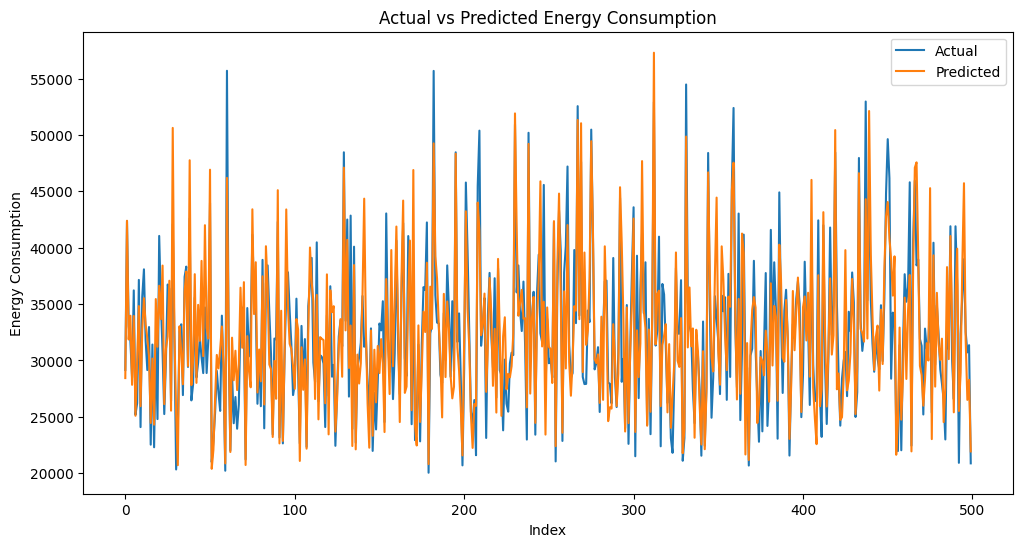

In [40]:
#Actual vs Predicted LIne plot
plt.figure(figsize=(12,6))
plt.plot(comparision['Actual'][:500],label='Actual')
plt.plot(comparision['Predicted'][:500],label='Predicted')
plt.title('Actual vs Predicted Energy Consumption')
plt.xlabel('Index')
plt.ylabel('Energy Consumption')
plt.legend()
plt.show()

This above line plot compares the actual and the predicted energy consumption values

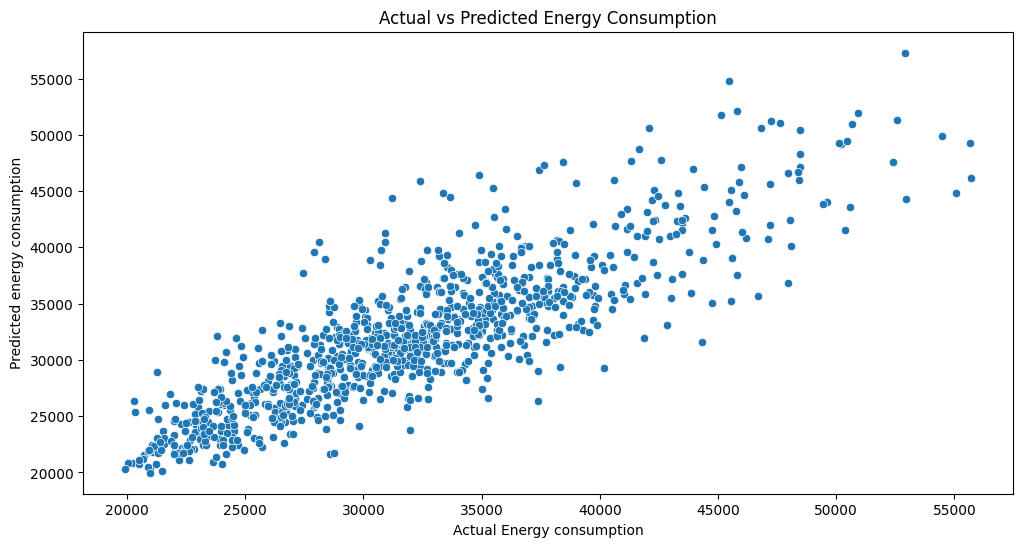

In [41]:
# Actual vs predicted scatter plot
plt.figure(figsize=(12,6))
sns.scatterplot(x=comparision['Actual'][:1000],y=comparision['Predicted'][:1000])
plt.title('Actual vs Predicted Energy Consumption')
plt.xlabel('Actual Energy consumption')
plt.ylabel('Predicted energy consumption')
plt.show()

this above scatter plot shows that the model closely follows the real consumption patterns

**ANOMALY DETECTION**

In [84]:
detection_model = IsolationForest(n_estimators=100,contamination=0.01,random_state=3)

In [85]:
detection_model.fit(X_train)

IsolationForest(contamination=0.01, random_state=3)

In [86]:
predictions = detection_model.predict(X)

In [87]:
predictions

array([1, 1, 1, ..., 1, 1, 1])

In [88]:
hourly_data['anomaly']= predictions

In [94]:
#created by mistake
hourly_data = hourly_data.drop(columns=['Anomaly'], errors='ignore')

In [95]:
subset = hourly_data.iloc[:500]

In [96]:
anomalies = subset[subset['anomaly']==-1]

In [97]:
# Counting anomalies in the first 500 samples
print("Number of anomalies in first 500 samples:", len(anomalies))

Number of anomalies in first 500 samples: 16


In [98]:
anomalies.head()

,Datetime,PJME_MW,hour,dayofWeek,month,dayofYear,weekand,anomaly
95,2002-01-05 00:00:00,30924.0,0,5,1,5,1,-1
117,2002-01-05 22:00:00,32022.0,22,5,1,5,1,-1
118,2002-01-05 23:00:00,30680.0,23,5,1,5,1,-1
119,2002-01-06 00:00:00,29011.0,0,6,1,6,1,-1
120,2002-01-06 01:00:00,27100.0,1,6,1,6,1,-1


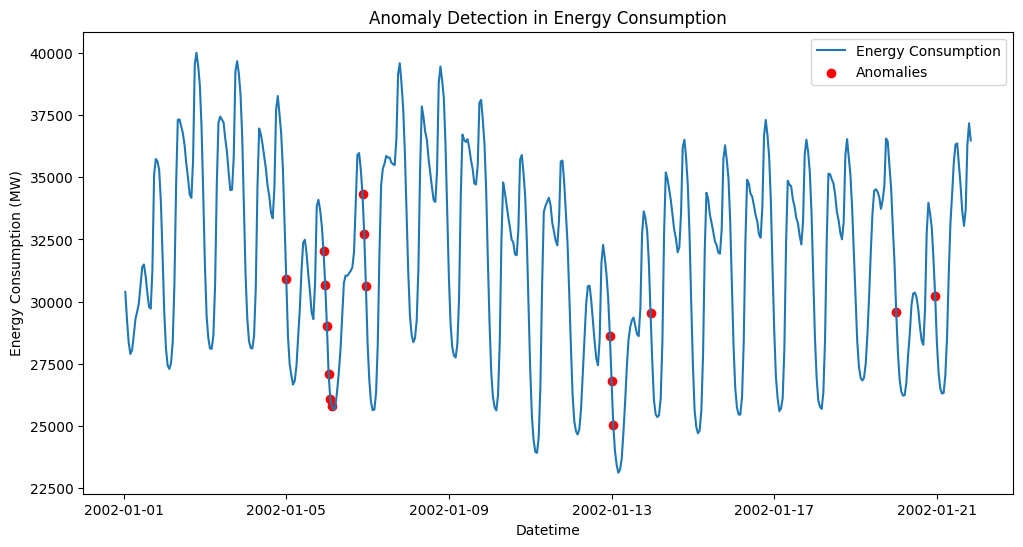

In [99]:
# Plotting Anomaly detection for the first 500 samples
plt.figure(figsize=(12, 6))
plt.plot(subset['Datetime'],subset['PJME_MW'],label='Energy Consumption')
plt.scatter(anomalies['Datetime'],anomalies['PJME_MW'],color='red',label='Anomalies')
plt.title('Anomaly Detection in Energy Consumption')
plt.xlabel('Datetime')
plt.ylabel('Energy Consumption (MW)')
plt.legend()
plt.show()

Saving the models

In [104]:
import pickle

In [108]:
with open('random_forest_model.pkl','wb') as file:
  pickle.dump(model,file)

In [107]:
with open('isolation_forest_model.pkl','wb') as file:
  pickle.dump(detection_model,file)


Downloading the files from google colab

In [110]:
from google.colab import files
files.download('random_forest_model.pkl')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [111]:
files.download('isolation_forest_model.pkl')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [103]:
plt.savefig('Anomaly Detection in Energy Consumption.png')

<Figure size 640x480 with 0 Axes>